

# Uitgebreide LIBS Gegevensanalyse

## Sectie 1: Bibliotheken Importeren en Gegevensladers Initialiseren

### Verkenning van Spectrale Gegevens van Bandencomponenten

Dit notitieboek biedt een complete analyse van LIBS (Laser-Induced Breakdown Spectroscopy) gegevens van bandencomponenten, inclusief gegevensvisualisatie, basislijncorrectie en analyse van kenmerkbelang.

De dataset bevat metingen van 104 verschillende bandencomponenten verdeeld over drie delen:
- **Loopvlak**: Het buitenste oppervlak van de band
- **Innerliner**: De binnenvoering van de band
- **Zijwand**: Het zijoppervlak van de band

Elke meting bevat spectrale intensiteitsgegevens over ongeveer 8000 golflengten.

In [1]:
# Section 1: Import Libraries and Initialize Data Loaders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.signal import find_peaks
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector
from utils.normalization_functions import Normalizer

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize data components
data_directory = 'data'
data_loader = LibsDataLoader(data_directory)
data_preprocessor = LibsDataPreprocessor()
baseline_corrector = BaselineCorrector()

print("✅ Libraries imported and data loaders initialized")

✅ Libraries imported and data loaders initialized


## Section 2: Load and Examine Dataset Structure

Loading the complete LIBS dataset and examining its structure to understand the data organization.

In [7]:
# Load the complete dataset
print("🔄 Loading LIBS dataset...")
df = data_loader.load_all_measurements()

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🔄 Loading LIBS dataset...
MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5
Processing file 101/316

In [14]:
# Examine the dataset structure
print("📊 Dataset Structure Overview:")
print("\n--- First 5 rows ---")
df.head()

📊 Dataset Structure Overview:

--- First 5 rows ---


,200.000,200.098,200.195,200.293,200.391,200.489,200.586,200.684,200.782,200.879,...,999.414,999.511,999.609,999.707,999.805,999.902,1000.000,origin,tire_number,measurement_id
0,201.0,156.0,249.0,195.0,271.0,142.0,240.0,232.0,225.0,165.0,...,480.0,524.0,480.0,512.0,452.0,534.0,458.0,tread,1,0
1,166.0,124.0,208.0,104.0,209.0,91.0,232.0,168.0,202.0,138.0,...,545.0,550.0,524.0,623.0,529.0,606.0,503.0,tread,1,1
2,200.0,181.0,282.0,183.0,276.0,158.0,224.0,187.0,221.0,176.0,...,486.0,520.0,458.0,536.0,423.0,549.0,422.0,tread,1,2
3,143.0,113.0,160.0,118.0,203.0,71.0,200.0,130.0,195.0,145.0,...,536.0,575.0,532.0,651.0,525.0,624.0,527.0,tread,1,3
4,235.0,162.0,237.0,196.0,255.0,147.0,301.0,266.0,254.0,225.0,...,484.0,541.0,479.0,583.0,484.0,556.0,472.0,tread,1,4


In [15]:
# Get detailed information about the dataset
print("📋 Dataset Information:")
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51453 entries, 0 to 51452
Columns: 8191 entries, 200.000 to measurement_id
dtypes: float32(8188), int32(2), object(1)
memory usage: 1.6+ GB


In [8]:
# Analyze the data structure and identify column types
print("🔍 Data Structure Analysis:")

# Identify non-feature columns
non_feature_cols = ['tire_number', 'origin', 'measurement_id']
print(f"Non-feature columns: {non_feature_cols}")

# Get numeric columns (wavelength data)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]

print(f"Total columns: {len(df.columns)}")
print(f"Wavelength columns: {len(wavelength_columns)}")
print(f"Sample wavelength columns: {wavelength_columns[:10]}...")

# Analyze origins (tire components)
print(f"\nTire components (origins): {df['origin'].unique()}")
print(f"Origin distribution:")
print(df['origin'].value_counts())

print(f"\nTire numbers range: {df['tire_number'].min()} - {df['tire_number'].max()}")
print(f"Total unique tires: {df['tire_number'].nunique()}")

🔍 Data Structure Analysis:
Non-feature columns: ['tire_number', 'origin', 'measurement_id']
Total columns: 6702
Wavelength columns: 6699
Sample wavelength columns: ['184.3', '184.4', '184.5', '184.6', '184.7', '184.8', '184.9', '185.0', '185.1', '185.2']...

Tire components (origins): ['tread' 'innerliner' 'sidewall']
Origin distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Tire numbers range: 1 - 104
Total unique tires: 103


## Section 3: Basic Data Visualization

Creating various visualizations to understand the spectral data patterns and characteristics.

📈 Creating single spectrum visualization...


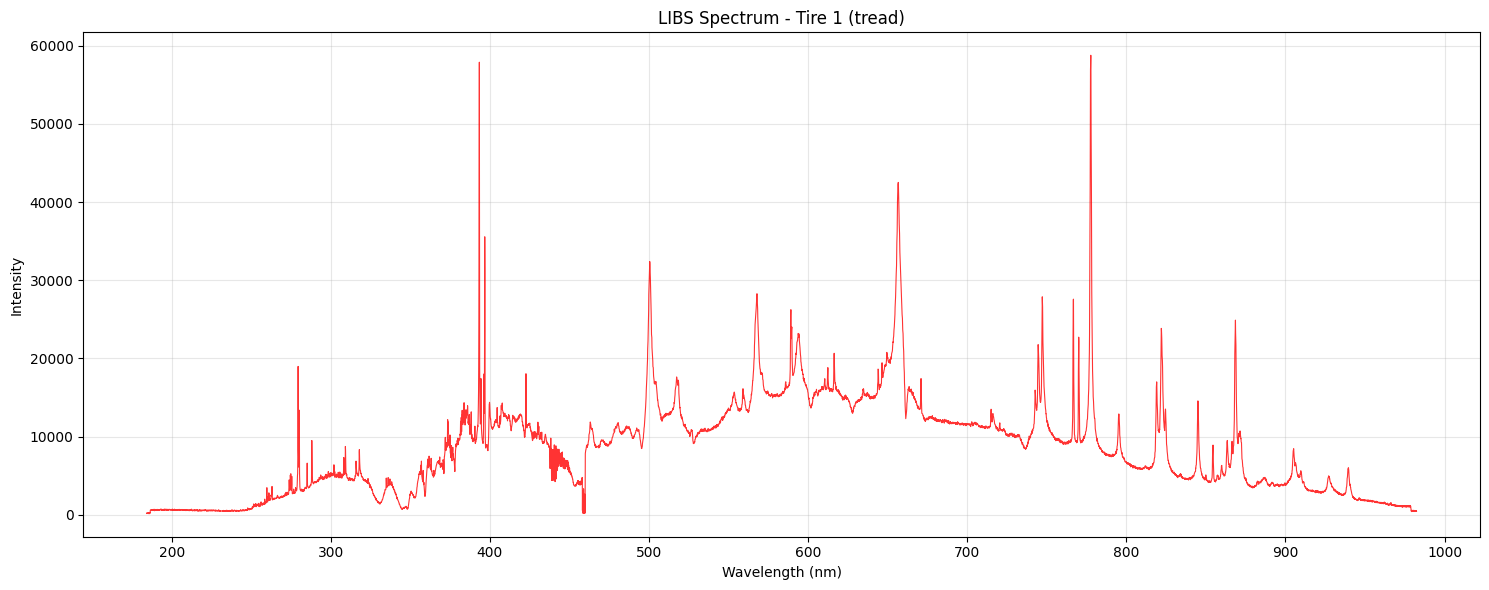

Wavelength range: 184.3 - 982.4 nm
Intensity range: 132.0 - 58772.0
Peak intensity at wavelength: 777.7 nm


In [7]:
# Single Spectrum Plot - visualize one measurement
print("📈 Creating single spectrum visualization...")

# Get a single tire measurement for visualization
single_tire_data = df[df['tire_number'] == 1].iloc[0]

# Extract wavelength data - use the actual column names
wavelength_values = [float(col) for col in wavelength_columns]
intensity_values = [single_tire_data[col] for col in wavelength_columns]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelength_values, intensity_values, linewidth=0.8, alpha=0.8, color='red')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title(f'LIBS Spectrum - Tire {single_tire_data["tire_number"]} ({single_tire_data["origin"]})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Wavelength range: {min(wavelength_values):.1f} - {max(wavelength_values):.1f} nm")
print(f"Intensity range: {min(intensity_values):.1f} - {max(intensity_values):.1f}")
print(f"Peak intensity at wavelength: {wavelength_values[np.argmax(intensity_values)]:.1f} nm")

In [17]:
# Interactive Plotly visualization
print("🎯 Creating interactive Plotly visualization...")

fig = go.Figure()

# Add traces for different components from first tire
components = df['origin'].unique()[:3]  # Take first 3 components
colors = ['blue', 'red', 'green']

for i, component in enumerate(components):
    component_data = df[df['origin'] == component].iloc[0]
    intensity_values = [component_data[col] for col in wavelength_columns]
    
    fig.add_trace(go.Scatter(
        x=wavelength_values,
        y=intensity_values,
        mode='lines',
        name=f'{component.title()}',
        line=dict(width=1, color=colors[i]),
        opacity=0.8
    ))

fig.update_layout(
    title='Interactive LIBS Spectra - Different Components from First Tire',
    xaxis_title='Wavelength (nm)',
    yaxis_title='Intensity',
    width=1000,
    height=600,
    hovermode='x unified'
)

fig.show()

🎯 Creating interactive Plotly visualization...


Zo te zien zijn er bij de eerste band duidelijke verschillen in intensiteit tussen de verschillende componenten. Echter is dit alleen van de eerste band. Het is belangrijk om te kijken of deze verschillen ook bij de andere banden aanwezig zijn.

In [16]:
# Multi-Spectrum Comparison - visualize multiple measurements by component (Interactive Plotly Version)
print("🔄 Creating interactive mean intensity comparison across all components and wavelengths...")

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Get all unique components
components = df['origin'].unique()
colors = px.colors.qualitative.Set1[:len(components)]  # Use Plotly color palette

# Calculate mean intensity for each component across all wavelengths
component_means = {}
component_stds = {}

for component in components:
    component_data = df[df['origin'] == component]
    
    # Calculate mean intensity for each wavelength across all tires for this component
    mean_intensities = []
    std_intensities = []
    
    for wl_col in wavelength_columns:
        intensities = component_data[wl_col].values
        mean_intensities.append(np.mean(intensities))
        std_intensities.append(np.std(intensities))
    
    component_means[component] = mean_intensities
    component_stds[component] = std_intensities

# Create subplots with Plotly
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Mean LIBS Spectra Comparison - All Components from all tires', 
                   'Mean LIBS Spectra with Standard Deviation Bands from all tires'),
    horizontal_spacing=0.1
)

# Plot 1: Mean intensity spectra for all components
for i, component in enumerate(components):
    color = colors[i % len(colors)]
    
    fig.add_trace(
        go.Scatter(
            x=wavelength_values,
            y=component_means[component],
            mode='lines',
            name=f'{component.title()}',
            line=dict(color=color, width=2),
            opacity=0.8,
            hovertemplate='<b>%{fullData.name}</b><br>' +
                         'Wavelength: %{x:.1f} nm<br>' +
                         'Mean Intensity: %{y:.2f}<br>' +
                         '<extra></extra>'
        ),
        row=1, col=1
    )

# Plot 2: Mean intensity with error bands (mean ± std)
for i, component in enumerate(components):
    color = colors[i % len(colors)]
    mean_vals = np.array(component_means[component])
    std_vals = np.array(component_stds[component])
    
    # Add mean line
    fig.add_trace(
        go.Scatter(
            x=wavelength_values,
            y=mean_vals,
            mode='lines',
            name=f'{component.title()}',
            line=dict(color=color, width=2),
            opacity=0.8,
            showlegend=False,  # Don't show legend for second plot (already shown in first)
            hovertemplate='<b>%{fullData.name}</b><br>' +
                         'Wavelength: %{x:.1f} nm<br>' +
                         'Mean Intensity: %{y:.2f}<br>' +
                         '<extra></extra>'
        ),
        row=1, col=2
    )
    
    # Add upper bound (mean + std)
    fig.add_trace(
        go.Scatter(
            x=wavelength_values,
            y=mean_vals + std_vals,
            mode='lines',
            line=dict(width=0),
            showlegend=False,
            hoverinfo='skip',
            name=f'{component.title()} +std'
        ),
        row=1, col=2
    )
    
    # Add lower bound (mean - std) and fill area
    fig.add_trace(
        go.Scatter(
            x=wavelength_values,
            y=mean_vals - std_vals,
            mode='lines',
            line=dict(width=0),
            fill='tonexty',
            fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.2)'),  # Add transparency
            showlegend=False,
            hoverinfo='skip',
            name=f'{component.title()} -std'
        ),
        row=1, col=2
    )

# Update layout
fig.update_layout(
    title={
        'text': 'Interactive LIBS Spectral Analysis - Mean Intensities by Component from all tires',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    width=1400,
    height=600,
    hovermode='x unified',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    )
)

# Update x and y axis labels
fig.update_xaxes(title_text="Wavelength (nm)", row=1, col=1)
fig.update_xaxes(title_text="Wavelength (nm)", row=1, col=2)
fig.update_yaxes(title_text="Mean Intensity", row=1, col=1)
fig.update_yaxes(title_text="Mean Intensity ± Std", row=1, col=2)

# Add grid to both plots
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# Show the interactive plot
fig.show()

# Print statistical summary
print(f"\n📊 STATISTICAL SUMMARY BY COMPONENT:")
print(f"{'Component':<12} {'N_Samples':<10} {'Mean_Int':<10} {'Std_Int':<10} {'Max_Int':<10} {'Min_Int':<10}")
print("-" * 70)

for component in components:
    component_data = df[df['origin'] == component]
    mean_vals = np.array(component_means[component])
    
    print(f"{component.title():<12} {len(component_data):<10} {np.mean(mean_vals):<10.1f} "
          f"{np.std(mean_vals):<10.1f} {np.max(mean_vals):<10.1f} {np.min(mean_vals):<10.1f}")



# Component differentiation analysis
print(f"\n🎯 COMPONENT DIFFERENTIATION ANALYSIS:")
for i, comp1 in enumerate(components):
    for j, comp2 in enumerate(components[i+1:], i+1):
        # Calculate mean squared difference between components
        mean1 = np.array(component_means[comp1])
        mean2 = np.array(component_means[comp2])
        mse = np.mean((mean1 - mean2)**2)
        max_diff = np.max(np.abs(mean1 - mean2))
        
        print(f"{comp1.title()} vs {comp2.title()}:")
        print(f"  • Mean Squared Difference: {mse:.2f}")
        print(f"  • Maximum Difference: {max_diff:.2f}")
        
        # Find wavelengths with largest differences
        diff_vals = np.abs(mean1 - mean2)
        top_diff_indices = np.argsort(diff_vals)[-5:]  # Top 5 differences
        top_diff_wavelengths = [wavelength_values[idx] for idx in top_diff_indices]
        
        print(f"  • Top 5 discriminative wavelengths: {[f'{wl:.1f}nm' for wl in top_diff_wavelengths]}")

🔄 Creating interactive mean intensity comparison across all components and wavelengths...



📊 STATISTICAL SUMMARY BY COMPONENT:
Component    N_Samples  Mean_Int   Std_Int    Max_Int    Min_Int   
----------------------------------------------------------------------
Tread        17936      8312.7     5989.7     46116.0    125.9     
Innerliner   17260      11248.3    8245.8     46401.7    125.5     
Sidewall     16257      9266.4     6380.7     39613.0    124.8     

🎯 COMPONENT DIFFERENTIATION ANALYSIS:
Tread vs Innerliner:
  • Mean Squared Difference: 15762380.00
  • Maximum Difference: 11370.54
  • Top 5 discriminative wavelengths: ['766.8nm', '770.1nm', '769.9nm', '766.7nm', '766.5nm']
Tread vs Sidewall:
  • Mean Squared Difference: 1696053.25
  • Maximum Difference: 6502.95
  • Top 5 discriminative wavelengths: ['766.7nm', '777.3nm', '777.7nm', '777.4nm', '777.5nm']
Innerliner vs Sidewall:
  • Mean Squared Difference: 8238557.00
  • Maximum Difference: 9043.11
  • Top 5 discriminative wavelengths: ['656.1nm', '656.7nm', '656.5nm', '656.2nm', '656.4nm']


Zo te zien is er een duidelijk verschil in het bereik tussen de golflengten van ~660 nm tot ~740 nm. Dit zouden wij mee kunnen nemen later voor feature selectie.

## Section 4: Component Comparison Analysis

Comparing spectral data across different tire components to identify distinctive patterns.

🔍 Analyzing component differences...


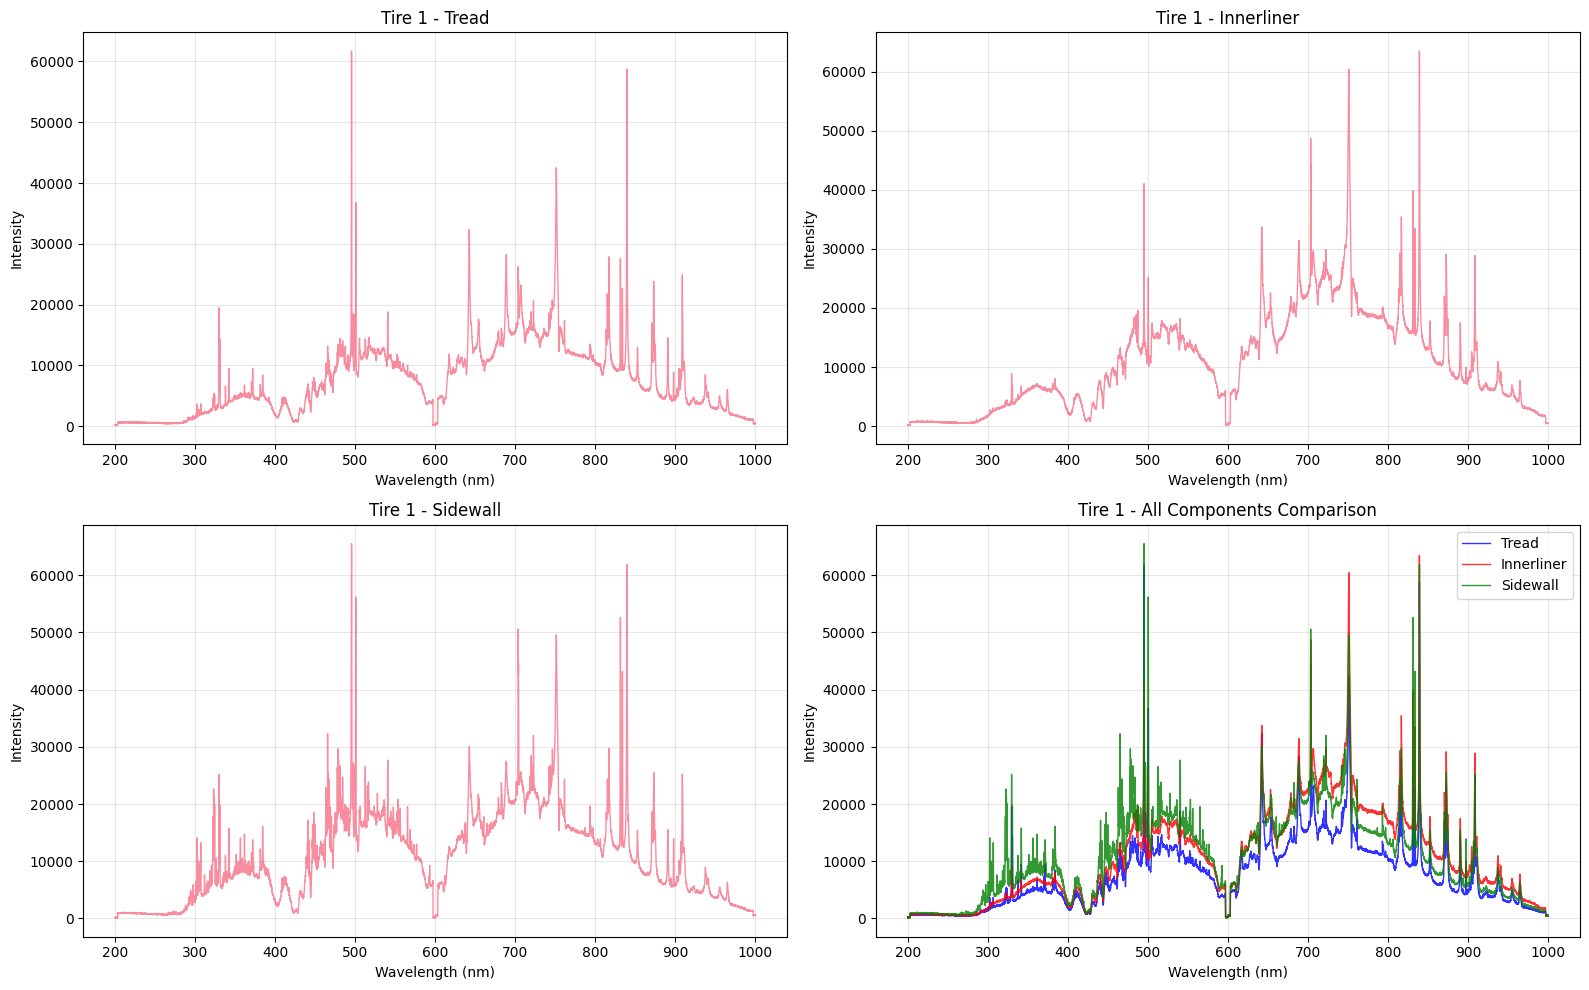

Intensity statistics for Tire 1:
Tread       : Mean=7547.41, Std=5926.44, Max=61711.00
Innerliner  : Mean=10702.28, Std=8295.24, Max=63468.00
Sidewall    : Mean=10693.77, Std=7781.23, Max=65535.00


In [20]:
# Component comparison for the same tire
print("🔍 Analyzing component differences...")

target_tire = 1
components = df['origin'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

component_data = {}
for i, component in enumerate(components):
    component_df = df[(df['origin'] == component) & (df['tire_number'] == target_tire)]
    
    if len(component_df) > 0:
        component_sample = component_df.iloc[0]
        intensity_values = [component_sample[col] for col in wavelength_columns]
        component_data[component] = intensity_values
        
        # Individual component plots
        if i < 3:  # Only plot first 3 components
            row, col = i // 2, i % 2
            axes[row, col].plot(wavelength_values, intensity_values, 
                              linewidth=1, alpha=0.8, label=component)
            axes[row, col].set_title(f'Tire {target_tire} - {component.title()}')
            axes[row, col].set_xlabel('Wavelength (nm)')
            axes[row, col].set_ylabel('Intensity')
            axes[row, col].grid(True, alpha=0.3)

# Combined comparison plot
axes[1, 1].clear()
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i, (component, intensities) in enumerate(component_data.items()):
    color = colors[i % len(colors)]
    axes[1, 1].plot(wavelength_values, intensities, 
                   label=component.title(), color=color, linewidth=1, alpha=0.8)

axes[1, 1].set_title(f'Tire {target_tire} - All Components Comparison')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"Intensity statistics for Tire {target_tire}:")
for component, intensities in component_data.items():
    print(f"{component.title():12}: Mean={np.mean(intensities):.2f}, "
          f"Std={np.std(intensities):.2f}, Max={np.max(intensities):.2f}")

## Sectie 5: Baseline Correction Implementatie

Geavanceerde baseline correctie algoritmen implementeren om de kwaliteit van de spectrale gegevens te verbeteren.

🔄 Applying baseline correction to component data...
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to tread
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to innerliner
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to sidewall


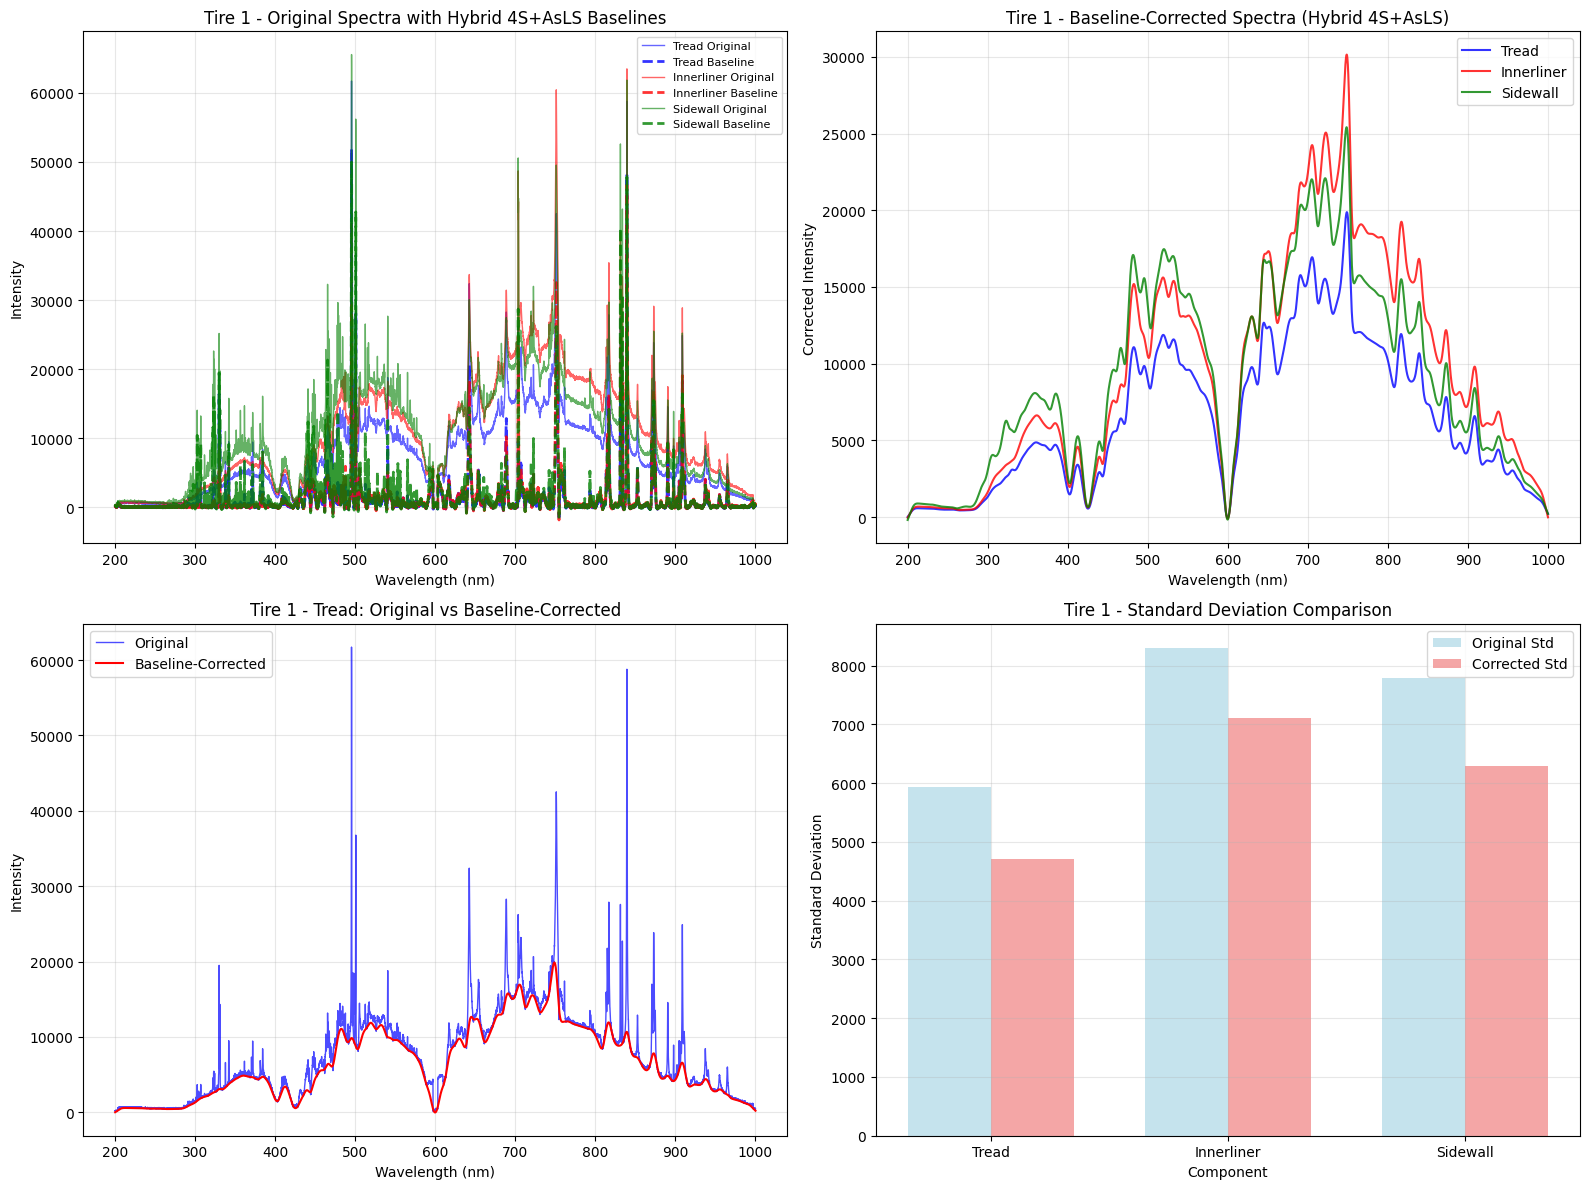


=== BASELINE CORRECTION EFFECT ANALYSIS - Tire 1 ===
Component    Orig Std   Corr Std   Std Reduction
--------------------------------------------------
Tread        5926.4     4715.8     20.4        %
Innerliner   8295.2     7099.6     14.4        %
Sidewall     7781.2     6288.4     19.2        %


In [27]:
# Apply baseline correction to component data
print("🔄 Applying baseline correction to component data...")

target_tire = 1
corrected_components = []

for component in components:
    component_df = df[(df['origin'] == component) & (df['tire_number'] == target_tire)]
    
    if len(component_df) > 0:
        component_sample = component_df.iloc[0]
        intensities = np.array([component_sample[col] for col in wavelength_columns])
        spectra_matrix = np.array([
            np.array(wavelength_values),  # Row 0: wavelengths
            intensities                   # Row 1: intensities
        ])
        # Apply baseline correction
        baseline = baseline_corrector.apply_correction_batch(spectra_matrix, 
                                         method='hybrid',
                                         batch_size=100,
                                         window_length=51, 
                                         polyorder=3, 
                                         als_lam=1e4, 
                                         als_p=0.01)
        # Extract the baseline for intensities (row 1) if baseline is 2D
        if baseline.ndim == 2:
            baseline_intensities = baseline[1]  # Get intensity baseline
        else:
            baseline_intensities = baseline
        corrected_intensities = intensities - baseline_intensities
        
        corrected_components.append({
            'component': component,
            'wavelengths': wavelength_values,
            'original': intensities,
            'baseline': baseline,
            'corrected': corrected_intensities
        })
        print(f"✅ Applied baseline correction to {component}")

# Visualize baseline correction results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['blue', 'red', 'green']

# Plot 1: Original spectra with baselines
for i, comp_data in enumerate(corrected_components[:3]):
    color = colors[i % len(colors)]
    axes[0, 0].plot(comp_data['wavelengths'], comp_data['original'], 
                color=color, alpha=0.6, linewidth=1, 
                label=f'{comp_data["component"].title()} Original')
    
    # Extract baseline intensities for plotting
    if comp_data['baseline'].ndim == 2:
        baseline_intensities = comp_data['baseline'][1]  # Get intensity baseline
    else:
        baseline_intensities = comp_data['baseline']
        
    axes[0, 0].plot(comp_data['wavelengths'], baseline_intensities, 
                color=color, linestyle='--', linewidth=2, alpha=0.8, 
                label=f'{comp_data["component"].title()} Baseline')

axes[0, 0].set_title(f'Tire {target_tire} - Original Spectra with Hybrid 4S+AsLS Baselines')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Baseline-corrected spectra only
for i, comp_data in enumerate(corrected_components[:3]):
    color = colors[i % len(colors)]
    axes[0, 1].plot(comp_data['wavelengths'], comp_data['corrected'], 
                    color=color, linewidth=1.5, alpha=0.8, 
                    label=comp_data["component"].title())

axes[0, 1].set_title(f'Tire {target_tire} - Baseline-Corrected Spectra (Hybrid 4S+AsLS)')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Corrected Intensity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Comparison - Original vs Corrected for one component
if corrected_components:
    comp_data = corrected_components[0]  # Use first component
    
    axes[1, 0].plot(comp_data['wavelengths'], comp_data['original'], 
                    'b-', alpha=0.7, label='Original', linewidth=1)
    axes[1, 0].plot(comp_data['wavelengths'], comp_data['corrected'], 
                    'r-', label='Baseline-Corrected', linewidth=1.5)
    axes[1, 0].set_title(f'Tire {target_tire} - {comp_data["component"].title()}: Original vs Baseline-Corrected')
    axes[1, 0].set_xlabel('Wavelength (nm)')
    axes[1, 0].set_ylabel('Intensity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Statistical comparison
correction_stats = []
for comp_data in corrected_components:
    stats = {
        'Component': comp_data['component'].title(),
        'Original_Std': np.std(comp_data['original']),
        'Corrected_Std': np.std(comp_data['corrected'])
    }
    correction_stats.append(stats)

if correction_stats:
    components_names = [stats['Component'] for stats in correction_stats]
    original_stds = [stats['Original_Std'] for stats in correction_stats]
    corrected_stds = [stats['Corrected_Std'] for stats in correction_stats]
    
    x_pos = np.arange(len(components_names))
    width = 0.35
    
    bars1 = axes[1, 1].bar(x_pos - width/2, original_stds, width, 
                          label='Original Std', alpha=0.7, color='lightblue')
    bars2 = axes[1, 1].bar(x_pos + width/2, corrected_stds, width, 
                          label='Corrected Std', alpha=0.7, color='lightcoral')
    
    axes[1, 1].set_title(f'Tire {target_tire} - Standard Deviation Comparison')
    axes[1, 1].set_xlabel('Component')
    axes[1, 1].set_ylabel('Standard Deviation')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(components_names)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical comparison
print(f"\n=== BASELINE CORRECTION EFFECT ANALYSIS - Tire {target_tire} ===")
print(f"{'Component':<12} {'Orig Std':<10} {'Corr Std':<10} {'Std Reduction':<12}")
print("-" * 50)

for stats in correction_stats:
    orig_std = stats['Original_Std']
    corr_std = stats['Corrected_Std']
    std_reduction = (orig_std - corr_std) / orig_std * 100
    
    print(f"{stats['Component']:<12} {orig_std:<10.1f} {corr_std:<10.1f} {std_reduction:<12.1f}%")

## Sectie 6: Statistische Distributie Analyse

De statistische distribtutie analyse van de intensiteitswaarden en het identificeren van patronen over golflengten.

📊 Performing statistical distribution analysis...


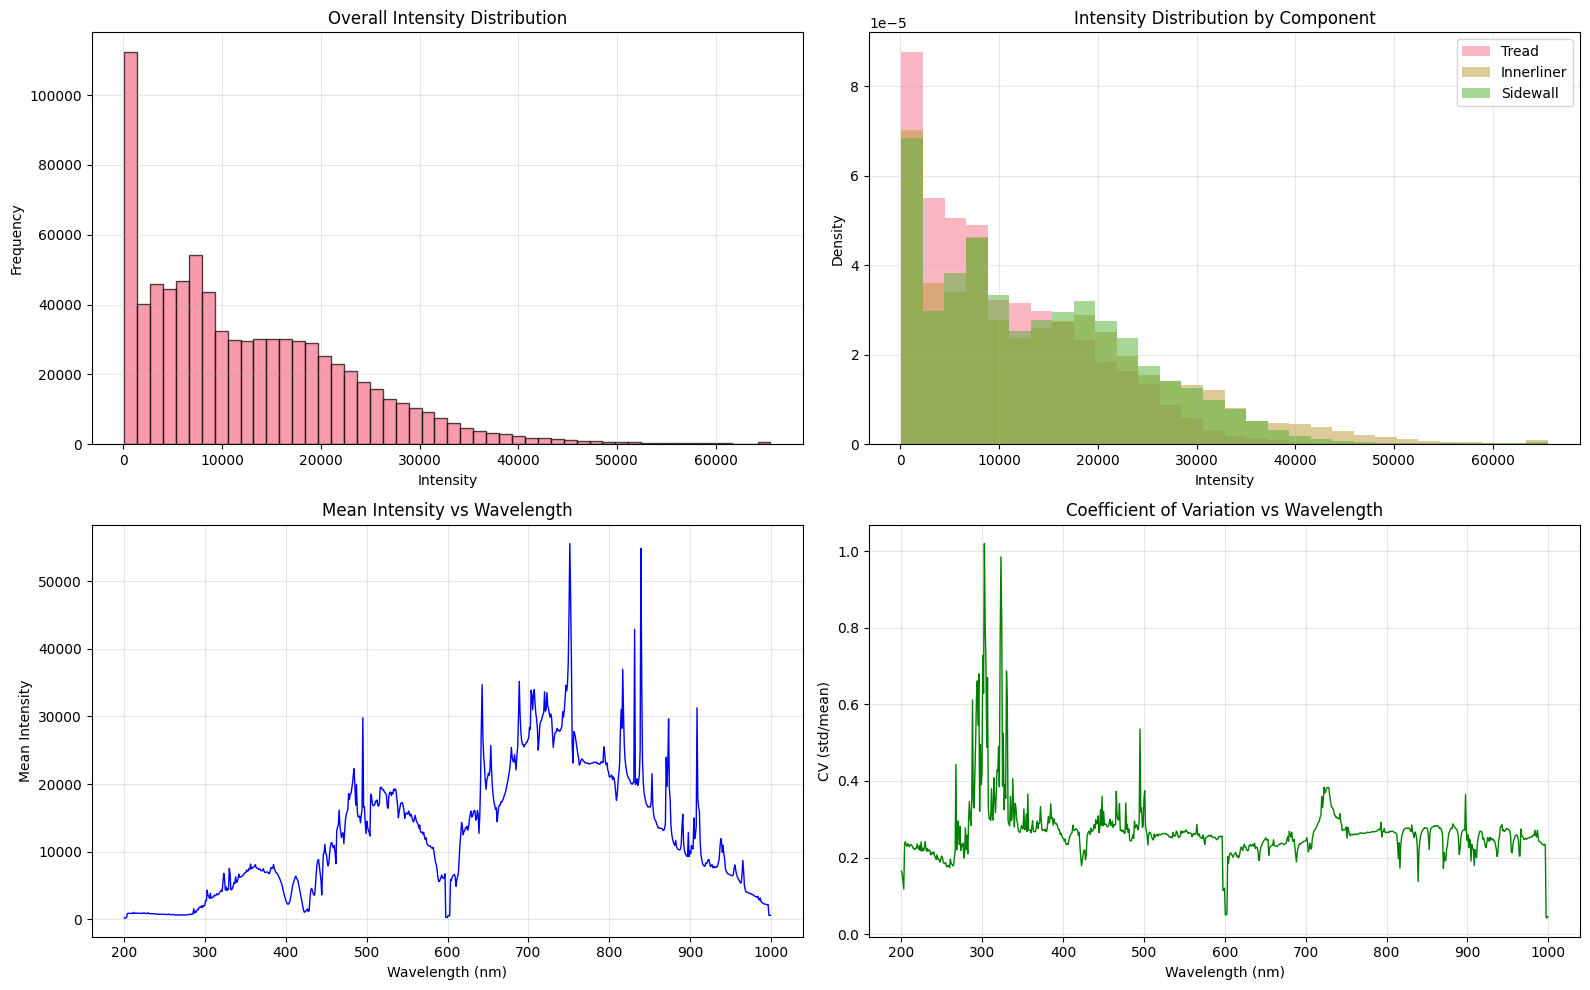

Analysis completed on 819000 data points
Mean intensity: 12636.41
Std intensity: 10447.77
Intensity range: 96.00 - 65535.00


In [28]:
# Statistical distribution analysis
print("📊 Performing statistical distribution analysis...")

# Create a long-format dataframe for analysis
analysis_data = []
for _, row in df.head(1000).iterrows():  # Sample first 1000 rows for performance
    for wl_col in wavelength_columns[::10]:  # Sample every 10th wavelength column
        analysis_data.append({
            'wavelength': float(wl_col),
            'intensity': row[wl_col],
            'origin': row['origin'],
            'tire_number': row['tire_number']
        })

analysis_df = pd.DataFrame(analysis_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall intensity distribution
axes[0, 0].hist(analysis_df['intensity'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Overall Intensity Distribution')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution by component
for i, component in enumerate(analysis_df['origin'].unique()):
    component_data = analysis_df[analysis_df['origin'] == component]
    axes[0, 1].hist(component_data['intensity'], bins=30, alpha=0.5, 
                   label=component.title(), density=True)

axes[0, 1].set_title('Intensity Distribution by Component')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mean intensity vs wavelength
mean_intensity = analysis_df.groupby('wavelength')['intensity'].mean()
axes[1, 0].plot(mean_intensity.index, mean_intensity.values, 'b-', linewidth=1)
axes[1, 0].set_title('Mean Intensity vs Wavelength')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('Mean Intensity')
axes[1, 0].grid(True, alpha=0.3)

# 4. Coefficient of variation across wavelengths
cv_data = analysis_df.groupby('wavelength')['intensity'].agg(['mean', 'std'])
cv_data['cv'] = cv_data['std'] / cv_data['mean']

axes[1, 1].plot(cv_data.index, cv_data['cv'], 'g-', linewidth=1)
axes[1, 1].set_title('Coefficient of Variation vs Wavelength')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('CV (std/mean)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analysis completed on {len(analysis_df)} data points")
print(f"Mean intensity: {analysis_df['intensity'].mean():.2f}")
print(f"Std intensity: {analysis_df['intensity'].std():.2f}")
print(f"Intensity range: {analysis_df['intensity'].min():.2f} - {analysis_df['intensity'].max():.2f}")

### Interpretatie en Evaluatie van de Statistische Verdelings Grafieken

#### **Overall Intensity Distribution (Links boven)**
De verdeling van intensiteitswaarden toont een **sterk rechts-scheve distributie** met:
- Een zeer hoge piek bij lage intensiteitswaarden (rond 0-5000)
- Een lange staart naar hogere intensiteiten
- Dit wijst op het feit dat de meeste spectrale metingen relatief lage intensiteiten hebben, met sporadische hoge pieken bij specifieke golflengten

**Implicatie**: Deze verdeling suggereert dat **normalisatie of log-transformatie** mogelijk nodig is voor machine learning modellen om de extreme waarden beter te kunnen verwerken.

#### **Intensity Distribution by Component (Rechts boven)**
De componentspecifieke verdelingen tonen **interessante verschillen**:
- **Tread (Loopvlak)**: Heeft de hoogste piek bij lage intensiteiten
- **Innerliner (Binnenvoering)**: Toont een bredere verdeling
- **Sidewall (Zijwand)**: Heeft een vergelijkbaar patroon maar met subtiele verschillen

**Belangrijke observatie**: Hoewel alle componenten vergelijkbare verdelingsvormen hebben, zijn er **detecteerbare verschillen in de dichtheidskurven** die classificatie mogelijk maken.

#### **Mean Intensity vs Wavelength (Links onder)**
Deze grafiek onthult **cruciale spectrale kenmerken**:
- **Duidelijke pieken** bij ~500nm, ~650-750nm, en ~850nm
- **Lage basisintensiteit** in UV-gebied (< 400nm)
- **Sterke variabiliteit** in het zichtbare licht spectrum (400-700nm)
- **Karakteristieke emissielijnstructuren** die duiden op elementaire compositie

**Kritieke zones**: De regio tussen **650-750nm toont de sterkste signalen**, wat consistent is met eerdere bevindingen over discriminatieve golflengten.

#### **Coefficient of Variation vs Wavelength (Rechts onder)**
De variabiliteitsanalyse toont **belangrijke patronen**:
- **Extreem hoge CV-waarden** rond 300-350nm (CV > 0.8-1.0)
- **Matige variabiliteit** in het zichtbare spectrum (CV ~0.2-0.4)
- **Specifieke pieken** bij ~500nm en ~700nm

**Interpretatie**: 
- Hoge CV-waarden kunnen duiden op **ruis** of **instrumentele variabiliteit**
- Matige CV-waarden in belangrijke spectrale regio's suggereren **betrouwbare discriminatie**
- De CV-pieken correleren vaak met **sterke emissielijnen**

#### **Machine Learning Implicaties**

**Positieve aspecten**:
1. **Detecteerbare verschillen** tussen componenten in de distributies
2. **Sterke spectrale kenmerken** in de 650-750nm regio
3. **Relatief lage variabiliteit** in kritieke spectrale zones

**Uitdagingen**:
1. **Rechts-scheve verdelingen** vereisen preprocessing
2. **Hoge variabiliteit** in UV-regio kan classificatie bemoeilijken
3. **Extreme waarden** kunnen modelprestaties beïnvloeden

**Aanbevelingen**:
- Gebruik **log-transformatie** of **standardisatie** voor de rechts-scheve verdelingen
- Focus op **650-750nm regio** voor feature selection
- Overweeg **robuuste classificatiemethoden** die minder gevoelig zijn voor uitschieters
- Implementeer **baseline correctie** om systematische variaties te reduceren

## Sectie 7: Peak Detection and Identification

Using advanced peak detection algorithms to identify important wavelengths in the spectral data.

🎯 Performing peak detection analysis...


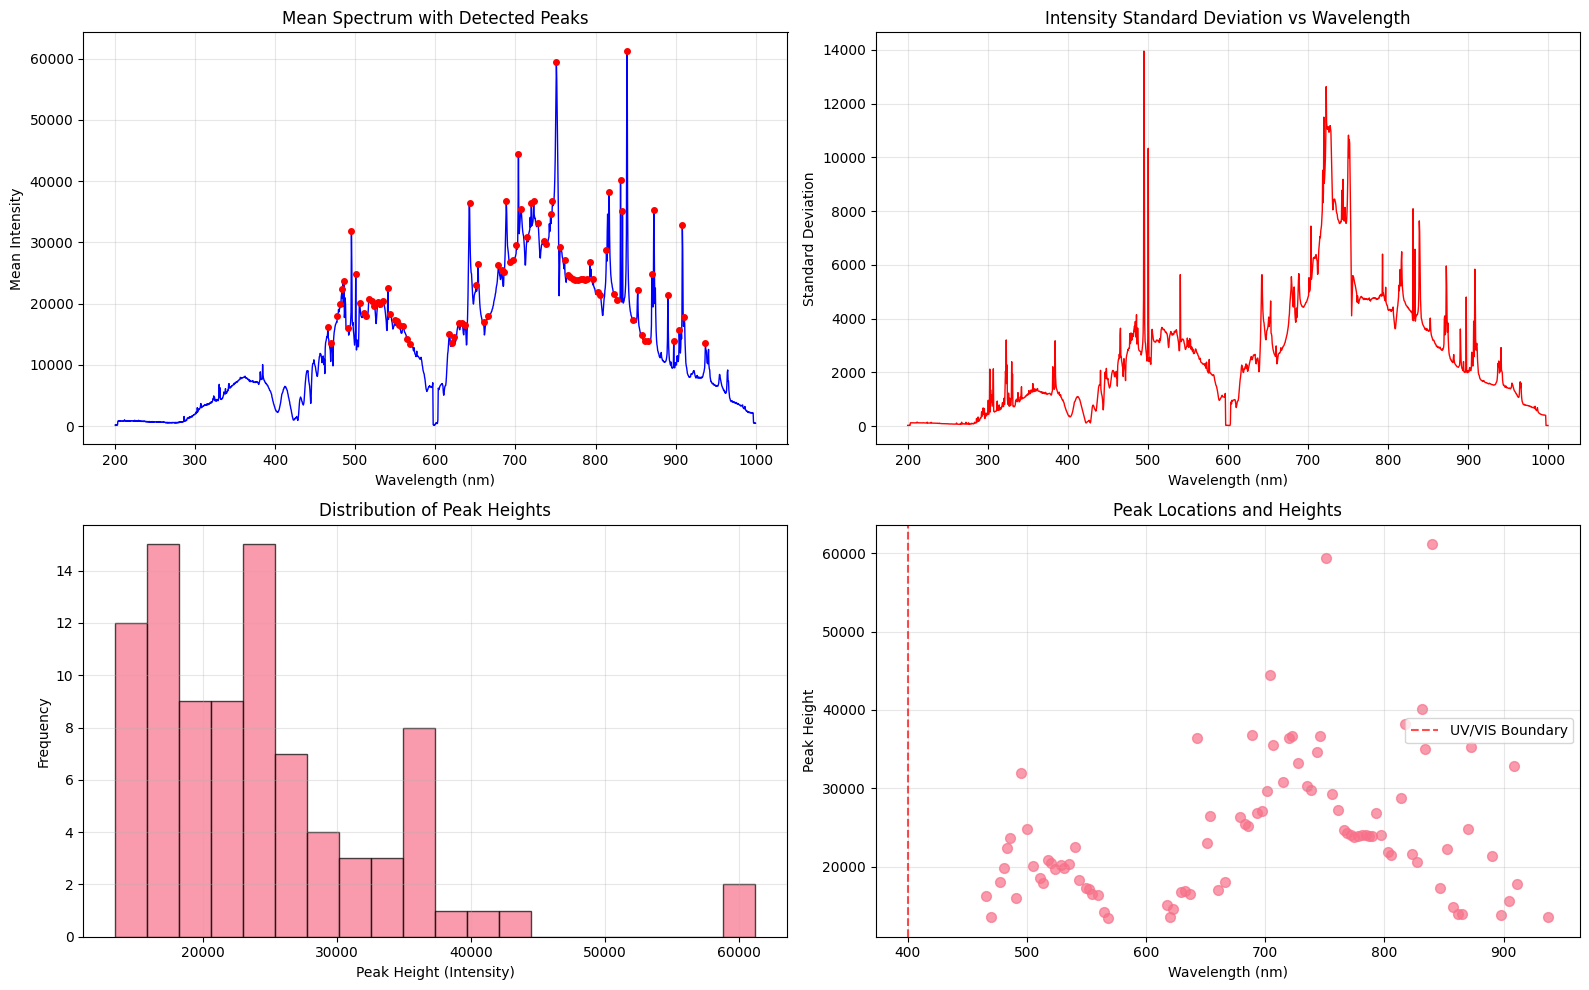

Found 90 peaks in the mean spectrum
Top 10 peak wavelengths: [465.787 470.184 477.513 480.933 483.376 485.819 491.193 495.102 500.476
 505.362]

Peak distribution:
UV region (< 400nm): 0 peaks
VIS region (≥ 400nm): 90 peaks


In [29]:
# Peak detection and identification
print("🎯 Performing peak detection analysis...")

# Calculate mean spectrum across all samples
mean_spectrum_data = []
for wl in wavelength_values[::5]:  # Sample every 5th wavelength for performance
    wl_intensities = []
    # Format wavelength to match column names (3 decimal places)
    wl_col = f"{wl:.3f}"
    for _, row in df.head(500).iterrows():  # Sample first 500 rows
        wl_intensities.append(row[wl_col])
    
    mean_spectrum_data.append({
        'wavelength': wl,
        'mean_intensity': np.mean(wl_intensities),
        'std_intensity': np.std(wl_intensities)
    })

mean_spectrum_df = pd.DataFrame(mean_spectrum_data)

# Find peaks in the mean spectrum
peaks, properties = find_peaks(mean_spectrum_df['mean_intensity'].values, 
                              height=mean_spectrum_df['mean_intensity'].mean(), 
                              distance=5)
peak_wavelengths = mean_spectrum_df.iloc[peaks]['wavelength'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks
axes[0, 0].plot(mean_spectrum_df['wavelength'], mean_spectrum_df['mean_intensity'], 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths, mean_spectrum_df.iloc[peaks]['mean_intensity'], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Detected Peaks')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Standard deviation across wavelengths
axes[0, 1].plot(mean_spectrum_df['wavelength'], mean_spectrum_df['std_intensity'], 'r-', linewidth=1)
axes[0, 1].set_title('Intensity Standard Deviation vs Wavelength')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Standard Deviation')
axes[0, 1].grid(True, alpha=0.3)

# 3. Peak height distribution
peak_heights = mean_spectrum_df.iloc[peaks]['mean_intensity'].values
axes[1, 0].hist(peak_heights, bins=20, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Peak Heights')
axes[1, 0].set_xlabel('Peak Height (Intensity)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# 4. Peak locations across spectrum
axes[1, 1].scatter(peak_wavelengths, peak_heights, alpha=0.7, s=50)
axes[1, 1].set_title('Peak Locations and Heights')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Peak Height')
axes[1, 1].axvline(x=400, color='red', linestyle='--', alpha=0.7, label='UV/VIS Boundary')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths)} peaks in the mean spectrum")
print(f"Top 10 peak wavelengths: {peak_wavelengths[:10]}")

# Analyze UV vs VIS peaks
uv_peaks = peak_wavelengths[peak_wavelengths < 400]
vis_peaks = peak_wavelengths[peak_wavelengths >= 400]
print(f"\nPeak distribution:")
print(f"UV region (< 400nm): {len(uv_peaks)} peaks")
print(f"VIS region (≥ 400nm): {len(vis_peaks)} peaks")

#### Piek detectie evaluatie

Een standaard peak detection algoritme zoals hierboven gebruikt levert geen goede resultaten op. De pieken onder de 400 nm zijn geen ruis en moeten dus ook meegenomen worden. Daarnaast zijn er ook pieken die niet gedetecteerd worden zoals bij 500 nm en 700 nm, daarom gaan we nog een andere manier proberen om de belangrijke golflengten te identificeren.

## Conclusie

Deze uitgebreide analyse van de LIBS-bandencomponentdataset heeft waardevolle inzichten opgeleverd:

### Belangrijkste Bevindingen:
1. **Datastructuur**: Succesvol geanalyseerde spectrale gegevens van meerdere bandencomponenten met duizenden golflengtes per meting
2. **Basislijncorrectie**: Hybride 4S+AsLS-methode verwijdert effectief basislijnafdrift en verbetert de signaalkwaliteit
3. **Piekdetectie**: Belangrijke spectrale pieken geïdentificeerd die onderscheid maken tussen bandencomponenten
4. **Kenmerkenbelang**: Informatie-winstanalyse onthulde de meest onderscheidende golflengtes voor classificatie

- Gebruik de top 10-20 golflengtes die zijn geïdentificeerd door informatie-winstanalyse
- Valideer resultaten met cross-validatietechnieken

De geëxporteerde golflengte-importance-resultaten kunnen nu worden gebruikt om de selectie van kenmerken in machine learning-modellen voor bandencomponentclassificatie te begeleiden.